In [18]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.0001)

Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.0001.txt
Starting to load ../../data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...


Loading sampled_SCZ_p0.0001.txt:  88%|████████▊ | 15.7M/17.9M [00:00<00:00, 21.5MB/s]


In [19]:
X = df.drop(columns=["Z", "ID"]).values
y = df["Z"].values

In [20]:
# write a script that inverts all features where the label is negative
import numpy as np

for i in range(X.shape[1]):
    X[:, i] = np.where(y.flatten() < 0, -X[:, i], X[:, i])
    # also change the label to positive for those samples


y = np.where(y.flatten() < 0, -y.flatten(), y.flatten()).reshape(-1, 1)

In [21]:
# box cox transformation on target
from scipy import stats
y, _ = stats.boxcox(y.flatten() + 1)  # add 1 to avoid issues with zero or negative values
y = y.reshape(-1, 1)

# do the inverse cube
#y = np.cbrt(y)

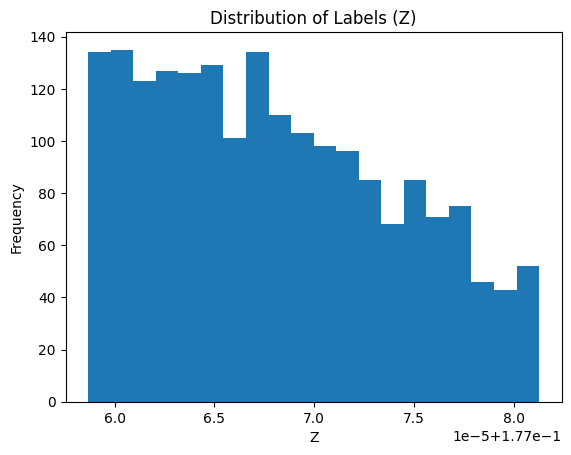

In [22]:
# plot distribution of labels
import matplotlib.pyplot as plt
plt.hist(y, bins=20)
plt.title("Distribution of Labels (Z)")
plt.xlabel("Z")
plt.ylabel("Frequency")
plt.show()

In [23]:
# sample from two different normal distributions with different means and variances
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split


from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
 
# implement cross validation with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear = LinearRegression()
    linear.fit(X_train_scaled, y_train)
    y_pred_linear = linear.predict(X_test_scaled)
    
    # correlation between y_test and y_pred_linear
    correlation_linear, p_value = pearsonr(y_test.flatten(), y_pred_linear.flatten())
    print(f"Correlation between y_test and y_pred_linear: {correlation_linear**2}")
    print(f"P-value: {p_value}")

Correlation between y_test and y_pred_linear: 0.011032080606037475
P-value: 0.038391274054097285
Correlation between y_test and y_pred_linear: 0.0036382173745077725
P-value: 0.2358728446132408
Correlation between y_test and y_pred_linear: 0.01509232155745578
P-value: 0.01546720067657507
Correlation between y_test and y_pred_linear: 0.008623948128854086
P-value: 0.06765751668046634
Correlation between y_test and y_pred_linear: 0.00811386366692392
P-value: 0.07636296820400171


In [16]:
df = load_illness_data("SCZ", in_notebook=True, distribution="low", p_value=0.0001)
X = df.drop(columns=["Z", "ID"]).values
y = df["Z"].values

Loading data for illness SCZ at ../../data/sampled/low/sampled_SCZ_p0.0001.txt
Starting to load ../../data/sampled/low/sampled_SCZ_p0.0001.txt with pandas...


Loading sampled_SCZ_p0.0001.txt:  88%|████████▊ | 15.7M/17.9M [00:00<00:00, 22.3MB/s]


In [17]:
# sample from two different normal distributions with different means and variances
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split


from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
 
# implement cross validation with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    linear = LinearRegression()
    linear.fit(X_train_scaled, y_train)
    y_pred_linear = linear.predict(X_test_scaled)
    
    # correlation between y_test and y_pred_linear
    correlation_linear, p_value = pearsonr(y_test.flatten(), y_pred_linear.flatten())
    print(f"Correlation between y_test and y_pred_linear: {correlation_linear**2}")
    print(f"P-value: {p_value}")

Correlation between y_test and y_pred_linear: 0.033163937869033336
P-value: 0.00030567670682189063
Correlation between y_test and y_pred_linear: 0.013908227035377864
P-value: 0.020145188294223276
Correlation between y_test and y_pred_linear: 0.030304898011576722
P-value: 0.0005725204096940458
Correlation between y_test and y_pred_linear: 0.06379750939699659
P-value: 4.626191823567232e-07
Correlation between y_test and y_pred_linear: 0.02863648179810158
P-value: 0.0008177280325546122
